# Reward Router Training: SQL to Training (Second Approach)

This notebook demonstrates the **reward-prediction approach** for VLM routing:

1. Load profiling data from PostgreSQL (real schema: `vlm_samples`, `vlm_responses`, `vlm_evaluations`, `vlm_images`)
2. Compute multi-objective rewards (accuracy, cheap, fast, balanced)
3. Build dataset where each row = (sample, model, mode) with scalar reward target
4. Train a transformer-based router to predict reward for any (query, model, mode) triple
5. Evaluate: compare router vs oracle on selecting best model

**Key Idea**: The router learns to predict how well each model will perform for a given query and mode, then chooses the model with highest predicted reward.

In [1]:
%load_ext autoreload
%autoreload 2

## Setup

In [2]:
# Add parent directory to path for imports
import sys
import os

# Get the notebook directory and add parent to path
notebook_dir = os.getcwd()
router_train_dir = os.path.dirname(notebook_dir)
sys.path.insert(0, router_train_dir)

print(f"Notebook dir: {notebook_dir}")
print(f"Router train dir: {router_train_dir}")

Notebook dir: /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/notebooks
Router train dir: /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train


In [3]:
# Standard imports
import json
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import pearsonr
from tqdm.auto import tqdm
from transformers import AutoTokenizer, get_linear_schedule_with_warmup


/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [4]:


# Project imports
from config import Config, DBConfig, RewardWeights
from db_utils import load_profiles_real_schema, load_from_sqlite, test_connection
from reward_definitions import compute_rewards_real_schema
from models.reward_router import RewardRouterModel
from training.dataset import build_dataloaders, split_by_data_split_column

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

# Matplotlib settings
plt.style.use('default')
%matplotlib inline

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✓ Imports successful")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA available: {torch.cuda.is_available()}")

✓ Imports successful
✓ PyTorch version: 2.9.1+cu128
✓ CUDA available: True


## 1. Connect to Database

Connect to PostgreSQL and verify the connection.

In [5]:
# # Load database configuration
# db_config = DBConfig.from_env()

# # Load database configuration
# db_config = DBConfig.from_env()

# # Current default: ngrok (remote PACE)
# DB_MODE = "ngrok"

# # Connections:
# if DB_MODE == "ngrok":
#     db_config.host = "4.tcp.ngrok.io"
#     db_config.port = 16035
# else:
#     db_config.host = "localhost"
#     db_config.port = 5432


# print("[DB CONFIG]")
# print(f"  Host: {db_config.host}")
# print(f"  Port: {db_config.port}")
# print(f"  Database: {db_config.name}")
# print(f"  User: {db_config.user}")

# # Test connection
# print("\n[TESTING CONNECTION]")
# if test_connection(db_config):
#     print("✓ Database connection successful!")
# else:
#     print("✗ Database connection failed!")
#     raise RuntimeError("Could not connect to database")

## 2. Load and Inspect Joined Profiles

Load data from all 4 tables using the real schema:
- `vlm_samples`: sample metadata
- `vlm_responses`: model responses with cost/latency
- `vlm_evaluations`: glider scores (0-5)
- `vlm_images`: image dimensions

In [6]:
# Load profiles from SQLite cache or database (flip the flag below)
USE_SQLITE_CACHE = True  # Set False to fetch directly from PostgreSQL
SQLITE_DB_PATH = Path(router_train_dir) / "data" / "vlm_router_cache.db"
SQLITE_TABLE_NAME = "vlm_profiles"

# Set limit=1000 for quick testing, or None for full dataset
LIMIT = None  # Change to e.g. 1000 for quick testing
DATA_SPLIT = None  # Optional: "train", "val", "test"

print("[LOADING PROFILES]")
if USE_SQLITE_CACHE:
    if not SQLITE_DB_PATH.exists():
        print(f"  SQLite file not found at {SQLITE_DB_PATH}, falling back to DB")
    else:
        print(f"  Source: SQLite -> {SQLITE_DB_PATH} ({SQLITE_TABLE_NAME})")
        df_profiles = load_from_sqlite(
            db_path=SQLITE_DB_PATH,
            table_name=SQLITE_TABLE_NAME,
            data_split=DATA_SPLIT,
            limit=LIMIT,
        )

if not USE_SQLITE_CACHE or "df_profiles" not in locals():
    print(f"  Source: PostgreSQL -> {db_config.host}:{db_config.port}/{db_config.name}")
    df_profiles = load_profiles_real_schema(
        db_config=db_config,
        data_split=DATA_SPLIT,
        limit=LIMIT,
    )

print(f"\n[LOADED DATA]")
print(f"  Total rows: {len(df_profiles):,}")
print(f"  Unique samples: {df_profiles['sample_id'].nunique():,}")
print(f"  Unique models: {df_profiles['model_name'].nunique()}")
print(f"  Columns: {list(df_profiles.columns)}")

2025-12-06 17:05:11,282 - db_utils - INFO - Created SQLite engine for /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/data/vlm_router_cache.db
2025-12-06 17:05:11,282 - db_utils - INFO - Loading from /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/data/vlm_router_cache.db:vlm_profiles
2025-12-06 17:05:11,302 - db_utils - INFO - Loaded 2218 rows
2025-12-06 17:05:11,302 - db_utils - INFO -   Unique samples: 570
2025-12-06 17:05:11,303 - db_utils - INFO -   Unique models: 5
2025-12-06 17:05:11,304 - db_utils - INFO -   Data splits: {'train': 750, 'test': 740, 'val': 728}


[LOADING PROFILES]
  Source: SQLite -> /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/data/vlm_router_cache.db (vlm_profiles)

[LOADED DATA]
  Total rows: 2,218
  Unique samples: 570
  Unique models: 5
  Columns: ['sample_id', 'source_config', 'source_dataset', 'router_task', 'data_split', 'prompt_raw', 'txt_prompt_length_chars', 'txt_prompt_length_words', 'img_width', 'img_height', 'img_aspect_ratio', 'model_name', 'model_prefix', 'latency_ms', 'cost_usd', 'confidence_score', 'glider_score']


In [7]:
# Inspect first few rows
display(df_profiles.head())

,sample_id,source_config,source_dataset,router_task,data_split,prompt_raw,txt_prompt_length_chars,txt_prompt_length_words,img_width,img_height,img_aspect_ratio,model_name,model_prefix,latency_ms,cost_usd,confidence_score,glider_score
0,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_7b,m3,8598.0,0.000246,0.760264,4.0
1,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,gemma_3_27b,m5,10272.0,0.000097,0.832087,5.0
2,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,deepseek_ocr,m1,1254.0,0.000037,0.996436,0.0
3,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen3_vl_8b_thinking,m4,5033.0,0.001188,0.865371,4.0
4,chart2text_0_68249402,chart2text,cauldron,chart_captioning,test,Could you shed some light on the insights conv...,65,12,800,776,1.030928,qwen2_5_vl_3b,m2,6152.0,0.000098,0.831460,4.0


In [8]:
# Dataset statistics
print("[DATASET STATISTICS]")
print("\nModels:")
print(df_profiles['model_name'].value_counts())

print("\nSource datasets:")
print(df_profiles['source_dataset'].value_counts())

print("\nRouter tasks:")
print(df_profiles['router_task'].value_counts())

if 'data_split' in df_profiles.columns:
    print("\nData splits:")
    print(df_profiles['data_split'].value_counts())

[DATASET STATISTICS]

Models:
model_name
qwen2_5_vl_3b           551
qwen2_5_vl_7b           550
gemma_3_27b             549
qwen3_vl_8b_thinking    539
deepseek_ocr             29
Name: count, dtype: int64

Source datasets:
source_dataset
cauldron    2218
Name: count, dtype: int64

Router tasks:
router_task
chart_captioning       150
chart_reasoning        150
code_generation        150
diagram_captioning     150
diagram_reasoning      150
document_ocr           150
general_vqa            150
geometry_reasoning     150
handwriting_ocr        150
knowledge_vqa          150
meme_classification    150
table_math             150
spatial_reasoning      150
table_reasoning        150
icon_reasoning         118
Name: count, dtype: int64

Data splits:
data_split
train    750
test     740
val      728
Name: count, dtype: int64


[GLIDER SCORE DISTRIBUTION]
count    2218.000000
mean        3.310189
std         1.896343
min         0.000000
25%         4.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: glider_score, dtype: float64


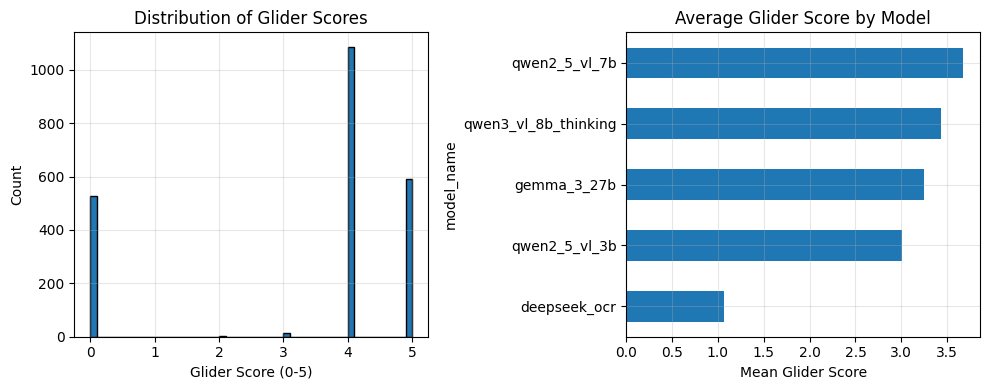

In [9]:
# Check glider_score distribution (our primary accuracy signal)
print("[GLIDER SCORE DISTRIBUTION]")
print(df_profiles['glider_score'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_profiles['glider_score'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Glider Score (0-5)')
plt.ylabel('Count')
plt.title('Distribution of Glider Scores')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
df_profiles.groupby('model_name')['glider_score'].mean().sort_values().plot(kind='barh')
plt.xlabel('Mean Glider Score')
plt.title('Average Glider Score by Model')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[COST AND LATENCY DISTRIBUTIONS]

Cost (USD):
count    2218.000000
mean        0.000314
std         0.000463
min         0.000005
25%         0.000041
50%         0.000104
75%         0.000324
max         0.003783
Name: cost_usd, dtype: float64

Latency (ms):
count     2218.000000
mean      2808.468440
std       3698.339284
min         46.000000
25%        419.250000
50%       1133.500000
75%       4409.250000
max      31359.000000
Name: latency_ms, dtype: float64


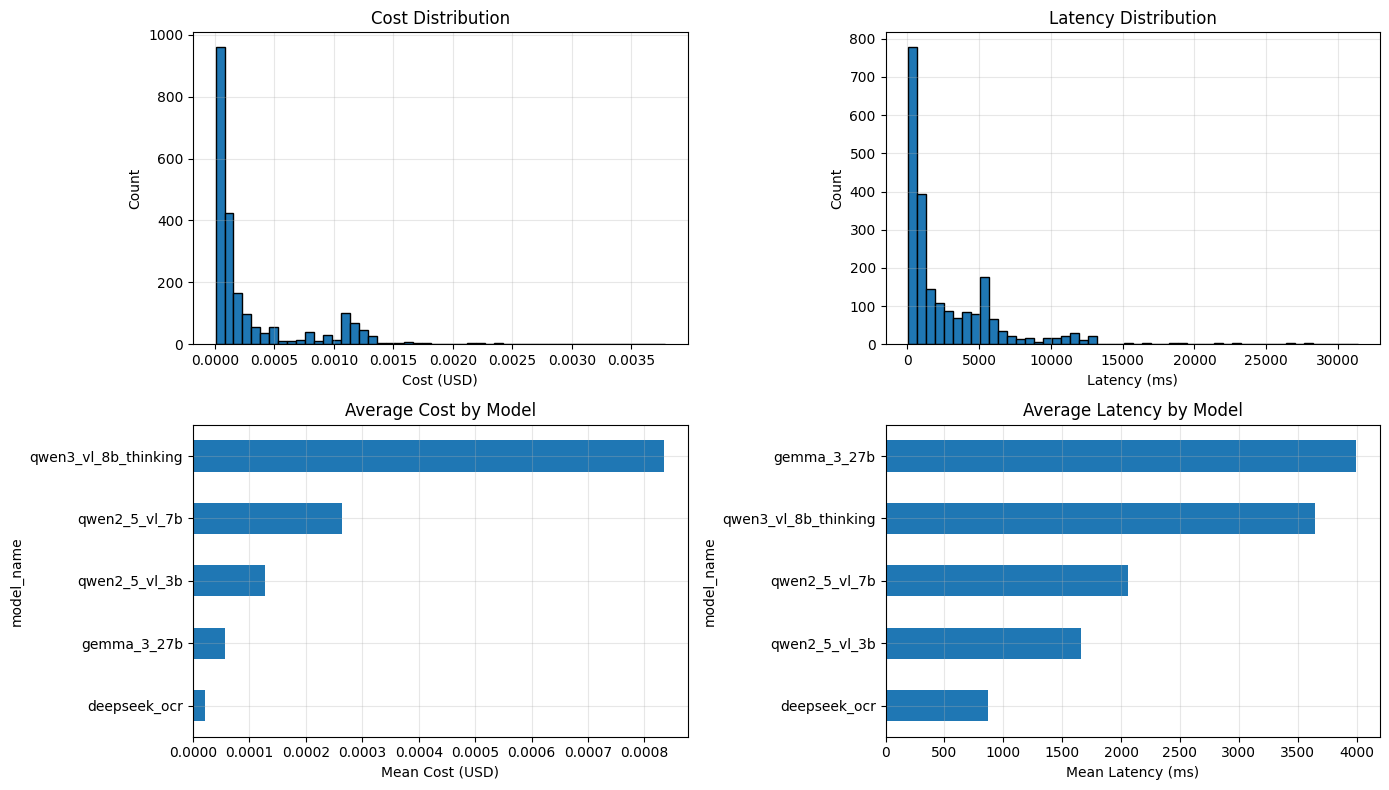

In [10]:
# Check cost and latency distributions
print("[COST AND LATENCY DISTRIBUTIONS]")
print("\nCost (USD):")
print(df_profiles['cost_usd'].describe())
print("\nLatency (ms):")
print(df_profiles['latency_ms'].describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Cost histogram
axes[0, 0].hist(df_profiles['cost_usd'].dropna(), bins=50, edgecolor='black')
axes[0, 0].set_xlabel('Cost (USD)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Cost Distribution')
axes[0, 0].grid(alpha=0.3)

# Latency histogram
axes[0, 1].hist(df_profiles['latency_ms'].dropna(), bins=50, edgecolor='black')
axes[0, 1].set_xlabel('Latency (ms)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Latency Distribution')
axes[0, 1].grid(alpha=0.3)

# Cost by model
df_profiles.groupby('model_name')['cost_usd'].mean().sort_values().plot(kind='barh', ax=axes[1, 0])
axes[1, 0].set_xlabel('Mean Cost (USD)')
axes[1, 0].set_title('Average Cost by Model')
axes[1, 0].grid(alpha=0.3)

# Latency by model
df_profiles.groupby('model_name')['latency_ms'].mean().sort_values().plot(kind='barh', ax=axes[1, 1])
axes[1, 1].set_xlabel('Mean Latency (ms)')
axes[1, 1].set_title('Average Latency by Model')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Compute Rewards & Expand Modes

Compute multi-objective rewards:
- **Accuracy**: $(A^2) \times H$ — maximize quality
- **Cheap**: $A \times H - 0.7 \times (cost\_norm^{1.2})$ — low cost
- **Fast**: $A \times H - 0.7 \times (lat\_norm^{1.2})$ — low latency
- **Balanced**: $(A^2) \times H + 0.3 \times (C^{0.5}) - 0.3 \times (cost^{1.1}) - 0.3 \times (lat^{1.1})$ — multi-objective

Where:
- $A$ = primary accuracy (glider_score / 5)
- $H$ = hallucination cleanliness (1.0, no signal available)
- $C$ = confidence (from confidence_score)
- $cost\_norm$, $lat\_norm$ = normalized cost/latency

In [11]:
# Initialize reward weights (using defaults)
reward_weights = RewardWeights()

print("[REWARD WEIGHTS]")
print(f"  Accuracy mode: A^{reward_weights.accuracy_exp} * H")
print(f"  Cheap mode: A*H - {reward_weights.cheap_cost_weight}*(cost^{reward_weights.cheap_cost_exp})")
print(f"  Fast mode: A*H - {reward_weights.fast_lat_weight}*(lat^{reward_weights.fast_lat_exp})")
print(f"  Balanced mode: A^{reward_weights.balanced_acc_exp}*H + {reward_weights.balanced_conf_weight}*C^{reward_weights.balanced_conf_exp}")
print(f"                  - {reward_weights.balanced_cost_weight}*cost^{reward_weights.balanced_cost_exp}")
print(f"                  - {reward_weights.balanced_lat_weight}*lat^{reward_weights.balanced_lat_exp}")

[REWARD WEIGHTS]
  Accuracy mode: A^2.0 * H
  Cheap mode: A*H - 0.7*(cost^1.2)
  Fast mode: A*H - 0.7*(lat^1.2)
  Balanced mode: A^2.0*H + 0.3*C^0.5
                  - 0.3*cost^1.1
                  - 0.3*lat^1.1


In [12]:
# Compute rewards
print("[COMPUTING REWARDS]")
df_rewards = compute_rewards_real_schema(df_profiles, reward_weights)

print(f"\n[REWARD COLUMNS ADDED]")
reward_cols = ['primary_acc', 'cost_norm', 'lat_norm', 'H', 'C', 
               'reward_accuracy', 'reward_cheap', 'reward_fast', 'reward_balanced']
print(f"  Columns: {reward_cols}")

2025-12-06 17:05:12,686 - reward_definitions - INFO - Computing rewards for all modes (using real schema with glider_score)...
2025-12-06 17:05:12,689 - reward_definitions - INFO - Using glider_score as primary accuracy (mean=0.662)
2025-12-06 17:05:12,692 - reward_definitions - INFO - Cost normalized: quantile=0.001229, mean=0.240
2025-12-06 17:05:12,692 - reward_definitions - INFO - Latency normalized: quantile=10657.30ms, mean=0.246
2025-12-06 17:05:12,693 - reward_definitions - INFO - Hallucination cleanliness H set to 1.0 (no hallucination signal available)
2025-12-06 17:05:12,694 - reward_definitions - INFO - Using confidence_score as C (mean=0.866)
2025-12-06 17:05:12,695 - reward_definitions - INFO - Reward (accuracy): mean=0.582, std=0.359
2025-12-06 17:05:12,696 - reward_definitions - INFO - Reward (cheap): mean=0.514, std=0.445
2025-12-06 17:05:12,697 - reward_definitions - INFO - Reward (fast): mean=0.515, std=0.430
2025-12-06 17:05:12,698 - reward_definitions - INFO - Rewa

[COMPUTING REWARDS]

[REWARD COLUMNS ADDED]
  Columns: ['primary_acc', 'cost_norm', 'lat_norm', 'H', 'C', 'reward_accuracy', 'reward_cheap', 'reward_fast', 'reward_balanced']


[REWARD DISTRIBUTIONS]


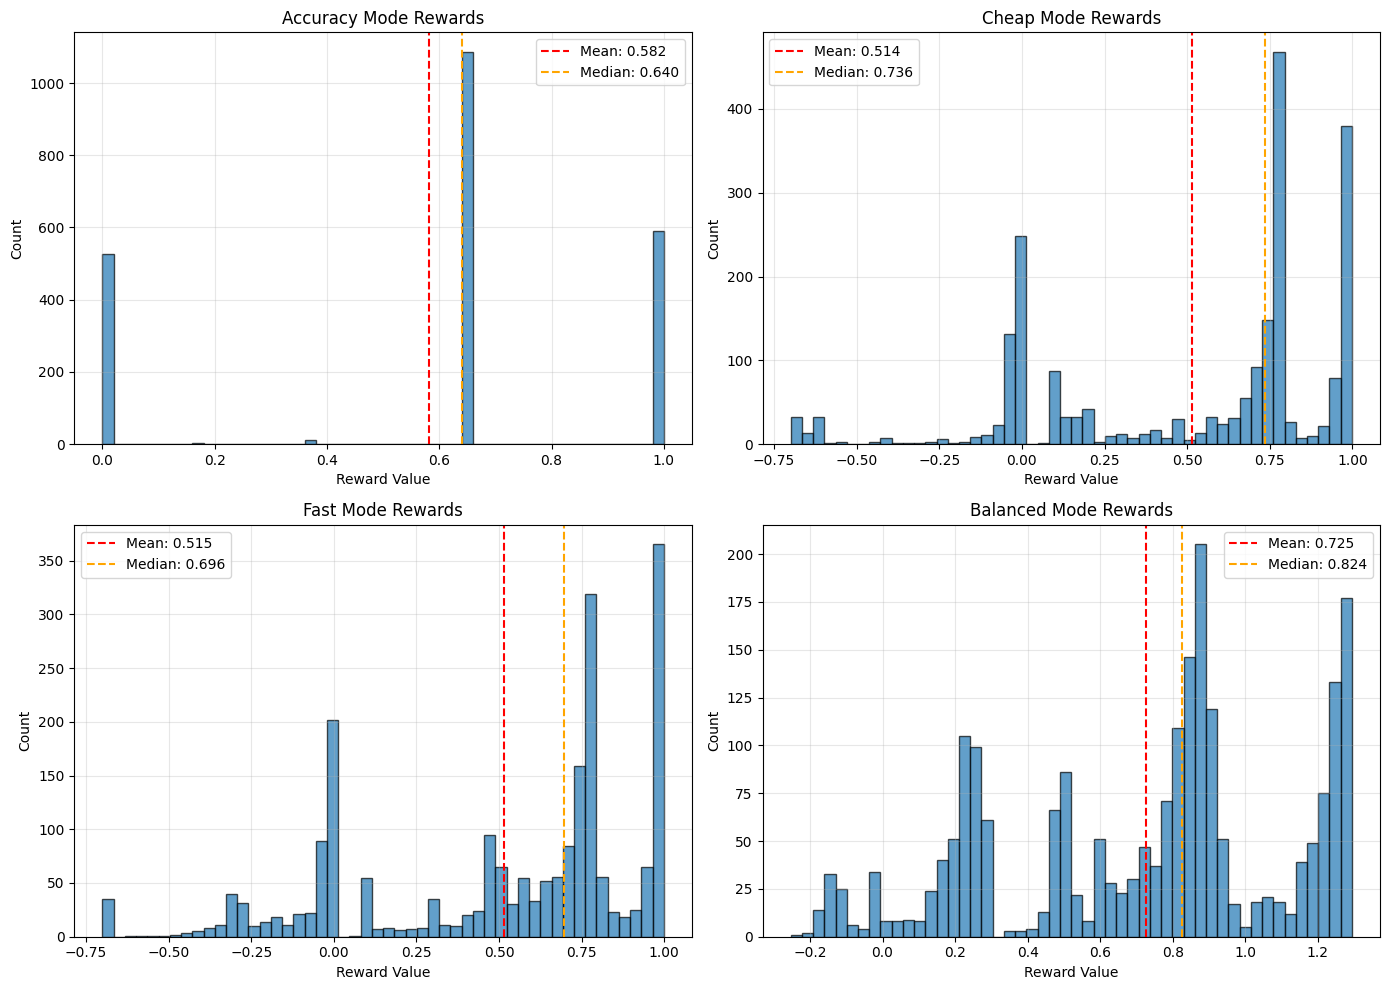


ACCURACY:
  Mean: 0.5821
  Std:  0.3592
  Min:  0.0000
  Max:  1.0000

CHEAP:
  Mean: 0.5137
  Std:  0.4449
  Min:  -0.7000
  Max:  0.9988

FAST:
  Mean: 0.5148
  Std:  0.4303
  Min:  -0.7000
  Max:  0.9988

BALANCED:
  Mean: 0.7250
  Std:  0.3999
  Min:  -0.2535
  Max:  1.2938


In [13]:
# Plot reward distributions
print("[REWARD DISTRIBUTIONS]")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, mode in enumerate(['accuracy', 'cheap', 'fast', 'balanced']):
    col = f'reward_{mode}'
    ax = axes[idx // 2, idx % 2]
    
    ax.hist(df_rewards[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(df_rewards[col].mean(), color='red', linestyle='--', label=f'Mean: {df_rewards[col].mean():.3f}')
    ax.axvline(df_rewards[col].median(), color='orange', linestyle='--', label=f'Median: {df_rewards[col].median():.3f}')
    ax.set_xlabel('Reward Value')
    ax.set_ylabel('Count')
    ax.set_title(f'{mode.capitalize()} Mode Rewards')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
for mode in ['accuracy', 'cheap', 'fast', 'balanced']:
    col = f'reward_{mode}'
    print(f"\n{mode.upper()}:")
    print(f"  Mean: {df_rewards[col].mean():.4f}")
    print(f"  Std:  {df_rewards[col].std():.4f}")
    print(f"  Min:  {df_rewards[col].min():.4f}")
    print(f"  Max:  {df_rewards[col].max():.4f}")

In [14]:
# Create model and mode mappings
print("[CREATING MODEL AND MODE MAPPINGS]")

model_names = sorted(df_rewards['model_name'].unique())
model2id = {m: i for i, m in enumerate(model_names)}
id2model = {i: m for m, i in model2id.items()}

mode_names = ['accuracy', 'cheap', 'fast', 'balanced']
mode2id = {m: i for i, m in enumerate(mode_names)}
id2mode = {i: m for m, i in mode2id.items()}

print(f"\nModels ({len(model_names)}):")
for model_name, model_id in model2id.items():
    print(f"  {model_id}: {model_name}")

print(f"\nModes ({len(mode_names)}):")
for mode_name, mode_id in mode2id.items():
    print(f"  {mode_id}: {mode_name}")

[CREATING MODEL AND MODE MAPPINGS]

Models (5):
  0: deepseek_ocr
  1: gemma_3_27b
  2: qwen2_5_vl_3b
  3: qwen2_5_vl_7b
  4: qwen3_vl_8b_thinking

Modes (4):
  0: accuracy
  1: cheap
  2: fast
  3: balanced


In [15]:
# Add model_id column
df_rewards['model_id'] = df_rewards['model_name'].map(model2id).astype('int64')

# Expand over modes: create one row per (sample, model, mode)
print("[EXPANDING OVER MODES]")
print(f"  Before expansion: {len(df_rewards):,} rows")

rows = []
for mode_name in mode_names:
    mode_id = mode2id[mode_name]
    reward_col = f'reward_{mode_name}'
    
    tmp = df_rewards.copy()
    tmp['mode_name'] = mode_name
    tmp['mode_id'] = mode_id
    tmp['reward'] = tmp[reward_col]
    
    rows.append(tmp)

df_router = pd.concat(rows, ignore_index=True)

print(f"  After expansion: {len(df_router):,} rows ({len(mode_names)} modes)")
print(f"  Unique (sample, model, mode) tuples: {len(df_router.groupby(['sample_id', 'model_id', 'mode_id']))}")

[EXPANDING OVER MODES]
  Before expansion: 2,218 rows
  After expansion: 8,872 rows (4 modes)
  Unique (sample, model, mode) tuples: 8872


In [16]:
# Select final training columns
cols_keep = [
    # Sample-level
    'sample_id',
    'prompt_raw',
    'source_config',
    'source_dataset',
    'router_task',
    'data_split',
    'txt_prompt_length_words',
    'txt_prompt_length_chars',
    'img_width',
    'img_height',
    'img_aspect_ratio',
    
    # Model-level
    'model_name',
    'model_id',
    
    # Mode-level
    'mode_name',
    'mode_id',
    
    # Target + debug
    'reward',
    'primary_acc',
    'cost_norm',
    'lat_norm',
    'H',
    'C',
]

# Filter to columns that exist
cols_keep = [c for c in cols_keep if c in df_router.columns]
df_train = df_router[cols_keep].copy()

print("[FINAL DATASET]")
print(f"  Shape: {df_train.shape}")
print(f"  Columns: {list(df_train.columns)}")

display(df_train.head())

[FINAL DATASET]
  Shape: (8872, 21)
  Columns: ['sample_id', 'prompt_raw', 'source_config', 'source_dataset', 'router_task', 'data_split', 'txt_prompt_length_words', 'txt_prompt_length_chars', 'img_width', 'img_height', 'img_aspect_ratio', 'model_name', 'model_id', 'mode_name', 'mode_id', 'reward', 'primary_acc', 'cost_norm', 'lat_norm', 'H', 'C']


,sample_id,prompt_raw,source_config,source_dataset,router_task,data_split,txt_prompt_length_words,txt_prompt_length_chars,img_width,img_height,...,model_name,model_id,mode_name,mode_id,reward,primary_acc,cost_norm,lat_norm,H,C
0,chart2text_0_68249402,Could you shed some light on the insights conv...,chart2text,cauldron,chart_captioning,test,12,65,800,776,...,qwen2_5_vl_7b,3,accuracy,0,0.64,0.8,0.199900,0.806771,1.0,0.760264
1,chart2text_0_68249402,Could you shed some light on the insights conv...,chart2text,cauldron,chart_captioning,test,12,65,800,776,...,gemma_3_27b,1,accuracy,0,1.00,1.0,0.079000,0.963846,1.0,0.832087
2,chart2text_0_68249402,Could you shed some light on the insights conv...,chart2text,cauldron,chart_captioning,test,12,65,800,776,...,deepseek_ocr,0,accuracy,0,0.00,0.0,0.029741,0.117666,1.0,0.996436
3,chart2text_0_68249402,Could you shed some light on the insights conv...,chart2text,cauldron,chart_captioning,test,12,65,800,776,...,qwen3_vl_8b_thinking,4,accuracy,0,0.64,0.8,0.966846,0.472258,1.0,0.865371
4,chart2text_0_68249402,Could you shed some light on the insights conv...,chart2text,cauldron,chart_captioning,test,12,65,800,776,...,qwen2_5_vl_3b,2,accuracy,0,0.64,0.8,0.079439,0.577257,1.0,0.831460


In [17]:
# Save dataset and indices
data_dir = os.path.join(router_train_dir, 'data')
os.makedirs(data_dir, exist_ok=True)

dataset_path = os.path.join(data_dir, 'router_reward_dataset.parquet')
model_index_path = os.path.join(data_dir, 'model_index.json')
mode_index_path = os.path.join(data_dir, 'mode_index.json')

print("[SAVING DATASET]")
df_train.to_parquet(dataset_path, index=False)
print(f"  ✓ Saved dataset: {dataset_path}")

with open(model_index_path, 'w') as f:
    json.dump({'name_to_id': model2id, 'id_to_name': id2model}, f, indent=2)
print(f"  ✓ Saved model index: {model_index_path}")

with open(mode_index_path, 'w') as f:
    json.dump({'name_to_id': mode2id, 'id_to_name': id2mode, 'names': mode_names}, f, indent=2)
print(f"  ✓ Saved mode index: {mode_index_path}")

[SAVING DATASET]
  ✓ Saved dataset: /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/data/router_reward_dataset.parquet
  ✓ Saved model index: /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/data/model_index.json
  ✓ Saved mode index: /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/data/mode_index.json


## 4. Build Dataset & Dataloaders

Split data by `data_split` column (train/val/test) and create PyTorch dataloaders.

In [18]:
# Split by data_split column
print("[SPLITTING DATASET]")
train_df, val_df, test_df = split_by_data_split_column(df_train)

print(f"\nTrain: {len(train_df):,} rows")
print(f"Val:   {len(val_df):,} rows")
print(f"Test:  {len(test_df):,} rows")

2025-12-06 17:05:14,170 - training.dataset - INFO - Dataset split by data_split column:
2025-12-06 17:05:14,171 - training.dataset - INFO -   Train: 3000 rows (193 unique samples)
2025-12-06 17:05:14,172 - training.dataset - INFO -   Val:   2912 rows (187 unique samples)
2025-12-06 17:05:14,172 - training.dataset - INFO -   Test:  2960 rows (190 unique samples)


[SPLITTING DATASET]

Train: 3,000 rows
Val:   2,912 rows
Test:  2,960 rows


In [19]:
# Load tokenizer
TEXT_ENCODER = "microsoft/deberta-v3-base"  # stronger encoder than distilbert
MAX_SEQ_LENGTH = 256
BATCH_SIZE = 24  # reduce a bit to fit larger encoder

print(f"[LOADING TOKENIZER: {TEXT_ENCODER}]")
tokenizer = AutoTokenizer.from_pretrained(TEXT_ENCODER)
print(f"  ✓ Tokenizer loaded")

[LOADING TOKENIZER: microsoft/deberta-v3-base]


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/home/hice1/vchopra37/scratch/projects/vlm_router/vlm_router_env/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


  ✓ Tokenizer loaded


In [20]:
# Build dataloaders
print("[BUILDING DATALOADERS]")
train_loader, val_loader, test_loader = build_dataloaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    tokenizer=tokenizer,
    batch_size=BATCH_SIZE,
    max_seq_length=MAX_SEQ_LENGTH,
    num_workers=0,  # Set to 0 for notebook to avoid multiprocessing issues
    pin_memory=False,
)

print(f"\n[DATALOADERS READY]")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val:   {len(val_loader)} batches")
print(f"  Test:  {len(test_loader)} batches")

2025-12-06 17:05:20,572 - training.dataset - INFO - Building dataloaders...
2025-12-06 17:05:20,573 - training.dataset - INFO - Created train dataset with 3000 samples
2025-12-06 17:05:20,574 - training.dataset - INFO - Created val dataset with 2912 samples
2025-12-06 17:05:20,574 - training.dataset - INFO - Created test dataset with 2960 samples
2025-12-06 17:05:20,575 - training.dataset - INFO - Created dataloaders:
2025-12-06 17:05:20,575 - training.dataset - INFO -   Train: 125 batches
2025-12-06 17:05:20,575 - training.dataset - INFO -   Val:   122 batches
2025-12-06 17:05:20,575 - training.dataset - INFO -   Test:  124 batches


[BUILDING DATALOADERS]

[DATALOADERS READY]
  Train: 125 batches
  Val:   122 batches
  Test:  124 batches


In [21]:
# Inspect a batch
print("[INSPECTING A BATCH]")
batch = next(iter(train_loader))

print(f"  input_ids: {batch['input_ids'].shape}")
print(f"  attention_mask: {batch['attention_mask'].shape}")
print(f"  model_id: {batch['model_id'].shape}")
print(f"  mode_id: {batch['mode_id'].shape}")
print(f"  reward: {batch['reward'].shape}")
print(f"\n  Example decoded text:")
print(f"  {tokenizer.decode(batch['input_ids'][0], skip_special_tokens=True)}")
print(f"\n  Example target reward: {batch['reward'][0].item():.4f}")
print(f"  Example model_id: {batch['model_id'][0].item()} ({id2model[batch['model_id'][0].item()]})")
print(f"  Example mode_id: {batch['mode_id'][0].item()} ({id2mode[batch['mode_id'][0].item()]})")

[INSPECTING A BATCH]
  input_ids: torch.Size([24, 256])
  attention_mask: torch.Size([24, 256])
  model_id: torch.Size([24])
  mode_id: torch.Size([24])
  reward: torch.Size([24])

  Example decoded text:
  [ROUTER] Task: chart_reasoning. Dataset: cauldron. SourceConfig: chartqa. Split: train. PromptLenWords: 17. ImgWidth: 310. ImgHeight: 376. ImgAR: 0.82. Question: What's the percentage of people asking the defense spending be cut back in 2016? Keep it brief.

  Example target reward: 0.0000
  Example model_id: 2 (qwen2_5_vl_3b)
  Example mode_id: 0 (accuracy)


## 5. Train Reward Router (Second Approach)

Train a transformer-based model that predicts reward for (query, model, mode) triples.

**Architecture**:
1. Text encoder (DistilBERT) → text embedding
2. Model embedding + Mode embedding
3. Concatenate → MLP → scalar reward prediction

**Loss**: MSE between predicted and true reward

In [22]:
# Training hyperparameters
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.05
GRADIENT_CLIP = 1.0
WARMUP_RATIO = 0.1  # % of steps for linear warmup

# Choose the best device (CUDA > MPS > CPU)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("[TRAINING CONFIGURATION]")
print(f"  Num epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Warmup ratio: {WARMUP_RATIO}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Device: {DEVICE}")
print(f"  Text encoder: {TEXT_ENCODER}")
print(f"  Max seq length: {MAX_SEQ_LENGTH}")

[TRAINING CONFIGURATION]
  Num epochs: 10
  Learning rate: 2e-05
  Weight decay: 0.05
  Warmup ratio: 0.1
  Batch size: 24
  Device: cuda
  Text encoder: microsoft/deberta-v3-base
  Max seq length: 256


In [23]:
# Initialize model
from config import RouterModelConfig

model_config = RouterModelConfig(
    text_encoder_name=TEXT_ENCODER,
    freeze_text_encoder=False,  # fine-tune encoder for better accuracy
    model_emb_dim=32,
    mode_emb_dim=16,
    hidden_dim=512,
    num_hidden_layers=3,
    dropout=0.2,
    max_seq_length=MAX_SEQ_LENGTH,
)

num_models = len(model2id)
num_modes = len(mode2id)

print(f"[INITIALIZING MODEL]")
print(f"  Num models: {num_models}")
print(f"  Num modes: {num_modes}")

model = RewardRouterModel(
    config=model_config,
    num_models=num_models,
    num_modes=num_modes,
)

model.to(DEVICE)

print(f"  ✓ Model initialized")
print(f"  Total parameters: {model.count_parameters():,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

2025-12-06 17:05:20,952 - models.reward_router - INFO - Loading text encoder: microsoft/deberta-v3-base


[INITIALIZING MODEL]
  Num models: 5
  Num modes: 4


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

2025-12-06 17:05:23,503 - models.reward_router - INFO - Text encoder hidden size: 768
2025-12-06 17:05:23,512 - models.reward_router - INFO - Model initialized with 184,775,905 trainable parameters


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

  ✓ Model initialized
  Total parameters: 184,775,905
  Trainable parameters: 184,775,905


In [24]:
# Setup optimizer, scheduler, and loss
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

criterion = nn.MSELoss()

print("[OPTIMIZER & LOSS]")
print(f"  Optimizer: AdamW")
print(f"  Loss: MSE")
print(f"  Total steps: {total_steps}")
print(f"  Warmup steps: {warmup_steps}")

[OPTIMIZER & LOSS]
  Optimizer: AdamW
  Loss: MSE
  Total steps: 1250
  Warmup steps: 125


In [25]:
# Training loop
history = {
    'train_loss': [],
    'val_loss': [],
    'val_pearson': [],
}

print("[TRAINING]")

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    
    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]") as pbar:
        for batch in pbar:
            # Move to device
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            model_id = batch['model_id'].to(DEVICE)
            mode_id = batch['mode_id'].to(DEVICE)
            reward = batch['reward'].to(DEVICE)
            
            # Forward
            optimizer.zero_grad()
            pred_reward = model(input_ids, attention_mask, model_id, mode_id)
            
            # Loss
            loss = criterion(pred_reward, reward)
            
            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item()
            pbar.set_postfix({'loss': f"{loss.item():.4f}", 'lr': f"{scheduler.get_last_lr()[0]:.2e}"})
    
    train_loss /= len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0.0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]") as pbar:
            for batch in pbar:
                # Move to device
                input_ids = batch['input_ids'].to(DEVICE)
                attention_mask = batch['attention_mask'].to(DEVICE)
                model_id = batch['model_id'].to(DEVICE)
                mode_id = batch['mode_id'].to(DEVICE)
                reward = batch['reward'].to(DEVICE)
                
                # Forward
                pred_reward = model(input_ids, attention_mask, model_id, mode_id)
                
                # Loss
                loss = criterion(pred_reward, reward)
                
                # Track
                val_loss += loss.item()
                all_preds.extend(pred_reward.cpu().numpy())
                all_targets.extend(reward.cpu().numpy())
                
                pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    val_loss /= len(val_loader)
    val_pearson, _ = pearsonr(all_preds, all_targets) if len(all_preds) > 1 else (0.0, None)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_pearson'].append(val_pearson)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Pearson: {val_pearson:.4f}")

print("[TRAINING COMPLETE]")

[TRAINING]


Epoch 1/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 0.3146 | Val Loss: 0.1735 | Val Pearson: 0.1666


Epoch 2/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.1337 | Val Loss: 0.1736 | Val Pearson: 0.2338


Epoch 10/10 [Train]:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.1292 | Val Loss: 0.1734 | Val Pearson: 0.2393
[TRAINING COMPLETE]


In [26]:
# Save trained model
checkpoints_dir = os.path.join(router_train_dir, 'models', 'checkpoints')
os.makedirs(checkpoints_dir, exist_ok=True)

model_save_path = os.path.join(checkpoints_dir, 'best_reward_router.pt')
model.save(model_save_path)
print(f"[MODEL SAVED] {model_save_path}")

2025-12-06 17:10:50,868 - models.reward_router - INFO - Model saved to: /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/models/checkpoints/best_reward_router.pt


[MODEL SAVED] /storage/ice1/1/0/vchopra37/projects/vlm_router/artemis_final/router_train/models/checkpoints/best_reward_router.pt


## 6. Plots & Diagnostics

Visualize training progress and evaluate router performance.

[TRAINING CURVES]


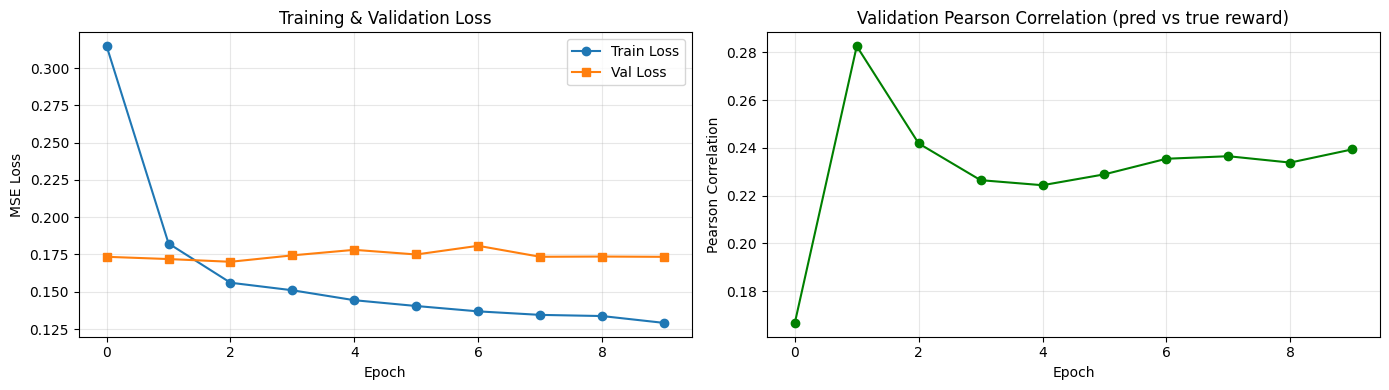


Final Val Loss: 0.1734
Final Val Pearson: 0.2393


In [27]:
# Plot training curves
print("[TRAINING CURVES]")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(history['train_loss'], marker='o', label='Train Loss')
axes[0].plot(history['val_loss'], marker='s', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Pearson correlation
axes[1].plot(history['val_pearson'], marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Pearson Correlation')
axes[1].set_title('Validation Pearson Correlation (pred vs true reward)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Val Loss: {history['val_loss'][-1]:.4f}")
print(f"Final Val Pearson: {history['val_pearson'][-1]:.4f}")

In [28]:
# Get predictions on validation set
print("[VALIDATION PREDICTIONS]")

model.eval()
val_preds = []
val_targets = []
val_sample_ids = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Predicting on val set"):
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        model_id = batch['model_id'].to(DEVICE)
        mode_id = batch['mode_id'].to(DEVICE)
        reward = batch['reward'].to(DEVICE)
        
        pred_reward = model(input_ids, attention_mask, model_id, mode_id)
        
        val_preds.extend(pred_reward.cpu().numpy())
        val_targets.extend(reward.cpu().numpy())
        val_sample_ids.extend(batch['sample_ids'])

val_preds = np.array(val_preds)
val_targets = np.array(val_targets)

print(f"  Collected {len(val_preds)} predictions")

[VALIDATION PREDICTIONS]


Predicting on val set:   0%|          | 0/122 [00:00<?, ?it/s]

  Collected 2912 predictions


[PREDICTED VS TRUE REWARD]


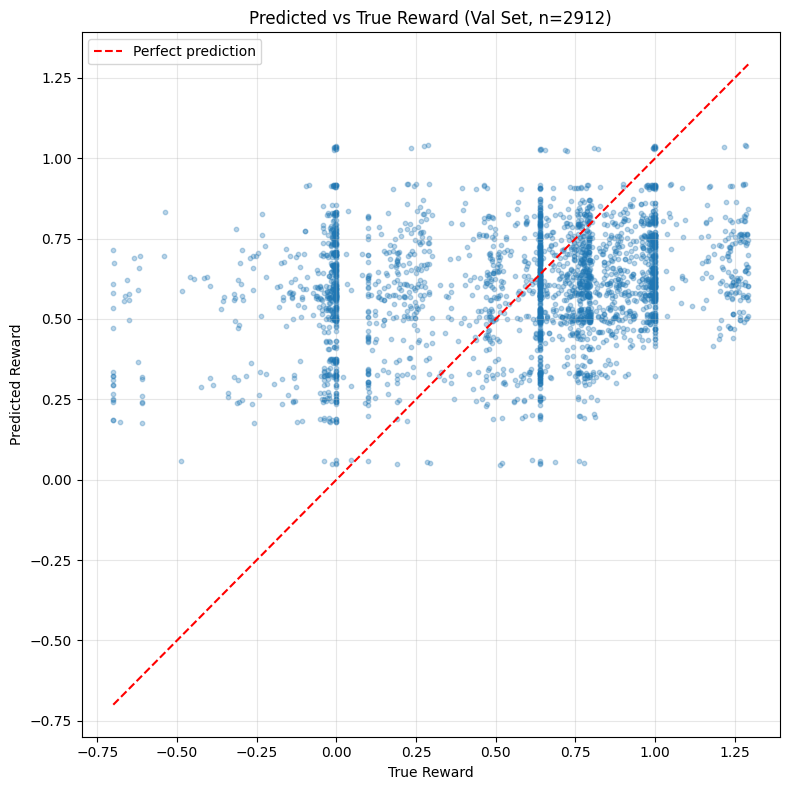


Pearson correlation: 0.2393


In [29]:
# Scatter plot: predicted vs true reward
print("[PREDICTED VS TRUE REWARD]")

# Random subsample for clarity
n_plot = min(5000, len(val_preds))
indices = np.random.choice(len(val_preds), size=n_plot, replace=False)

plt.figure(figsize=(8, 8))
plt.scatter(val_targets[indices], val_preds[indices], alpha=0.3, s=10)
plt.plot([val_targets.min(), val_targets.max()], 
         [val_targets.min(), val_targets.max()], 
         'r--', label='Perfect prediction')
plt.xlabel('True Reward')
plt.ylabel('Predicted Reward')
plt.title(f'Predicted vs True Reward (Val Set, n={n_plot})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr, _ = pearsonr(val_preds, val_targets)
print(f"\nPearson correlation: {corr:.4f}")

In [30]:
# Add predictions to val_df for oracle comparison
print("[ADDING PREDICTIONS TO VAL DF]")

val_df_with_preds = val_df.copy()
val_df_with_preds['pred_reward'] = val_preds

print(f"  Val df shape: {val_df_with_preds.shape}")
display(val_df_with_preds[['sample_id', 'model_name', 'mode_name', 'reward', 'pred_reward']].head(10))

[ADDING PREDICTIONS TO VAL DF]
  Val df shape: (2912, 22)


,sample_id,model_name,mode_name,reward,pred_reward
1490,chart2text_112_bceac724,gemma_3_27b,accuracy,1.00,0.536817
1491,chart2text_112_bceac724,qwen3_vl_8b_thinking,accuracy,0.64,0.527366
1492,chart2text_112_bceac724,qwen2_5_vl_7b,accuracy,1.00,0.537560
1493,chart2text_112_bceac724,qwen2_5_vl_3b,accuracy,0.64,0.530851
1494,chart2text_113_6591ac02,qwen2_5_vl_7b,accuracy,0.64,0.382537
1495,chart2text_113_6591ac02,gemma_3_27b,accuracy,0.64,0.381759
1496,chart2text_113_6591ac02,qwen3_vl_8b_thinking,accuracy,0.64,0.371705
1497,chart2text_113_6591ac02,qwen2_5_vl_3b,accuracy,0.00,0.375591
1498,chart2text_125_8f868ccc,qwen3_vl_8b_thinking,accuracy,0.64,0.497149
1499,chart2text_125_8f868ccc,qwen2_5_vl_7b,accuracy,0.64,0.507610


In [31]:
# Oracle vs Router comparison on a small subset
print("[ORACLE VS ROUTER COMPARISON]")

# For each (sample_id, mode_id), find:
#   - Oracle: model with max TRUE reward
#   - Router: model with max PREDICTED reward

results = []
unique_samples = val_df_with_preds['sample_id'].unique()[:100]  # Sample 100 for quick demo

for sample_id in tqdm(unique_samples, desc="Comparing oracle vs router"):
    sample_data = val_df_with_preds[val_df_with_preds['sample_id'] == sample_id]
    
    for mode_id in range(num_modes):
        mode_name = id2mode[mode_id]
        mode_data = sample_data[sample_data['mode_id'] == mode_id]
        
        if len(mode_data) == 0:
            continue
        
        # Oracle: max true reward
        oracle_idx = mode_data['reward'].idxmax()
        oracle_row = mode_data.loc[oracle_idx]
        
        # Router: max predicted reward
        router_idx = mode_data['pred_reward'].idxmax()
        router_row = mode_data.loc[router_idx]
        
        match = oracle_row['model_name'] == router_row['model_name']
        
        results.append({
            'sample_id': sample_id,
            'mode_name': mode_name,
            'oracle_model': oracle_row['model_name'],
            'oracle_reward': oracle_row['reward'],
            'router_model': router_row['model_name'],
            'router_pred_reward': router_row['pred_reward'],
            'router_true_reward': router_row['reward'],  # What the router actually got
            'match': match,
        })

results_df = pd.DataFrame(results)

print(f"\n[RESULTS ON {len(unique_samples)} SAMPLES]")
print(f"  Total decisions: {len(results_df)}")
print(f"  Router matches oracle: {results_df['match'].sum()} / {len(results_df)} ({100*results_df['match'].mean():.1f}%)")

# Show by mode
print("\n  By mode:")
for mode_name in mode_names:
    mode_results = results_df[results_df['mode_name'] == mode_name]
    if len(mode_results) > 0:
        match_rate = mode_results['match'].mean()
        print(f"    {mode_name:12s}: {100*match_rate:.1f}% match")

# Show a few examples
print("\n  Example comparisons:")
display(results_df.head(10))

[ORACLE VS ROUTER COMPARISON]


Comparing oracle vs router:   0%|          | 0/100 [00:00<?, ?it/s]


[RESULTS ON 100 SAMPLES]
  Total decisions: 400
  Router matches oracle: 82 / 400 (20.5%)

  By mode:
    accuracy    : 23.0% match
    cheap       : 7.0% match
    fast        : 30.0% match
    balanced    : 22.0% match

  Example comparisons:


,sample_id,mode_name,oracle_model,oracle_reward,router_model,router_pred_reward,router_true_reward,match
0,chart2text_112_bceac724,accuracy,gemma_3_27b,1.000000,qwen2_5_vl_7b,0.537560,1.000000,False
1,chart2text_112_bceac724,cheap,gemma_3_27b,0.970533,qwen2_5_vl_7b,0.536391,0.896109,False
2,chart2text_112_bceac724,fast,qwen2_5_vl_7b,0.800189,qwen2_5_vl_7b,0.535460,0.800189,True
3,chart2text_112_bceac724,balanced,qwen2_5_vl_7b,1.114247,qwen2_5_vl_7b,0.540486,1.114247,True
4,chart2text_113_6591ac02,accuracy,qwen2_5_vl_7b,0.640000,qwen2_5_vl_7b,0.382537,0.640000,True
5,chart2text_113_6591ac02,cheap,gemma_3_27b,0.779647,qwen2_5_vl_7b,0.381308,0.724815,False
6,chart2text_113_6591ac02,fast,qwen2_5_vl_7b,0.609807,qwen2_5_vl_7b,0.380260,0.609807,True
7,chart2text_113_6591ac02,balanced,qwen2_5_vl_7b,0.773461,qwen2_5_vl_7b,0.385385,0.773461,True
8,chart2text_125_8f868ccc,accuracy,gemma_3_27b,1.000000,qwen2_5_vl_7b,0.507610,0.640000,False
9,chart2text_125_8f868ccc,cheap,gemma_3_27b,0.973918,qwen2_5_vl_7b,0.506475,0.739453,False


[ROUTING ACCURACY BY MODE]


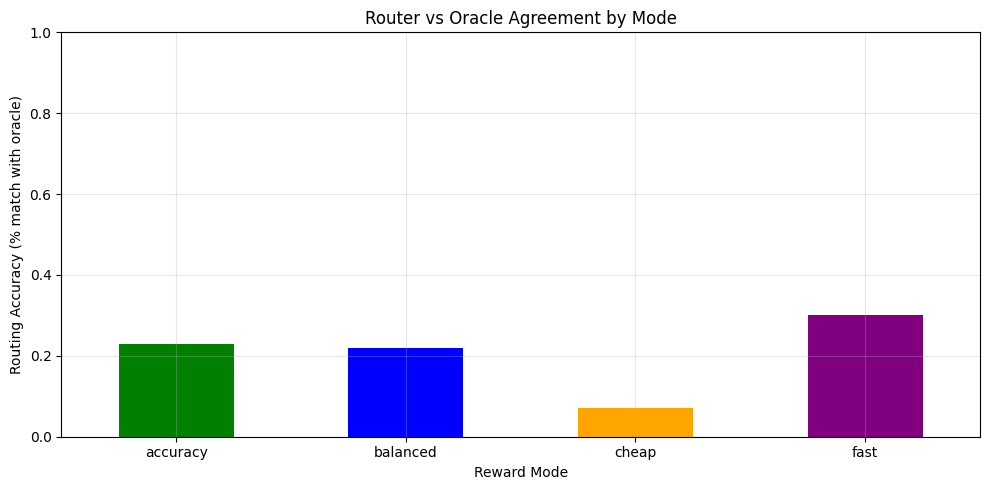


Interpretation:
  - Higher is better (router agrees with oracle more often)
  - Perfect score (1.0) = router always picks same model as oracle
  - Current overall accuracy: 20.5%


In [32]:
# Plot routing accuracy by mode
print("[ROUTING ACCURACY BY MODE]")

match_rates = results_df.groupby('mode_name')['match'].mean()

plt.figure(figsize=(10, 5))
match_rates.plot(kind='bar', color=['green', 'blue', 'orange', 'purple'])
plt.ylabel('Routing Accuracy (% match with oracle)')
plt.title('Router vs Oracle Agreement by Mode')
plt.xlabel('Reward Mode')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - Higher is better (router agrees with oracle more often)")
print("  - Perfect score (1.0) = router always picks same model as oracle")
print(f"  - Current overall accuracy: {100*results_df['match'].mean():.1f}%")

[REWARD RECOVERY ANALYSIS]

Average rewards:


,mode_name,oracle_reward,router_true_reward,reward_ratio
0,accuracy,0.752800,0.632000,0.839532
1,balanced,0.945309,0.784127,0.829493
2,cheap,0.765804,0.575210,0.751119
3,fast,0.738282,0.602255,0.815752


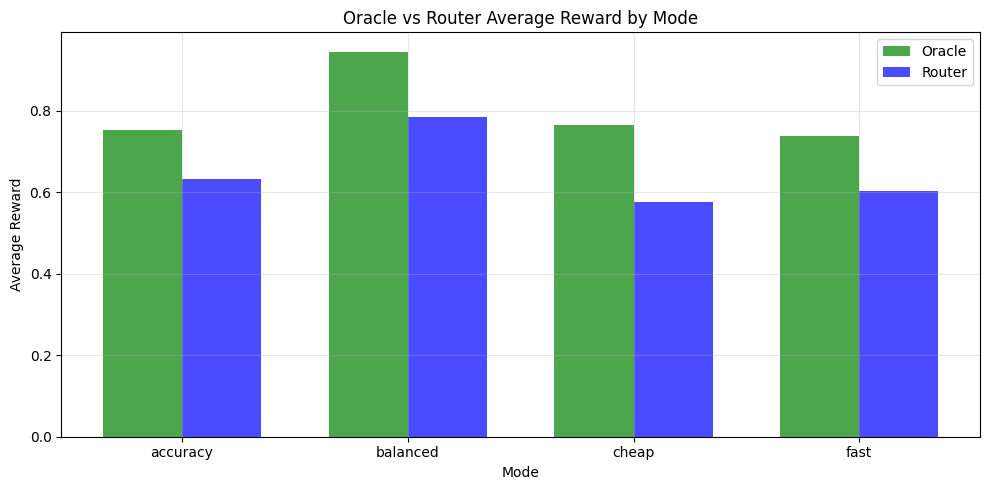


Reward recovery (router / oracle):
  accuracy    : 84.0%
  balanced    : 82.9%
  cheap       : 75.1%
  fast        : 81.6%


In [33]:
# Analyze router's reward recovery
print("[REWARD RECOVERY ANALYSIS]")

# How much reward does the router get vs oracle?
reward_comparison = results_df.groupby('mode_name').agg({
    'oracle_reward': 'mean',
    'router_true_reward': 'mean',
}).reset_index()

reward_comparison['reward_ratio'] = reward_comparison['router_true_reward'] / reward_comparison['oracle_reward']

print("\nAverage rewards:")
display(reward_comparison)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(reward_comparison))
width = 0.35

ax.bar(x - width/2, reward_comparison['oracle_reward'], width, label='Oracle', color='green', alpha=0.7)
ax.bar(x + width/2, reward_comparison['router_true_reward'], width, label='Router', color='blue', alpha=0.7)

ax.set_xlabel('Mode')
ax.set_ylabel('Average Reward')
ax.set_title('Oracle vs Router Average Reward by Mode')
ax.set_xticks(x)
ax.set_xticklabels(reward_comparison['mode_name'])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nReward recovery (router / oracle):")
for _, row in reward_comparison.iterrows():
    print(f"  {row['mode_name']:12s}: {100*row['reward_ratio']:.1f}%")

[PERFORMANCE DIAGNOSTICS]


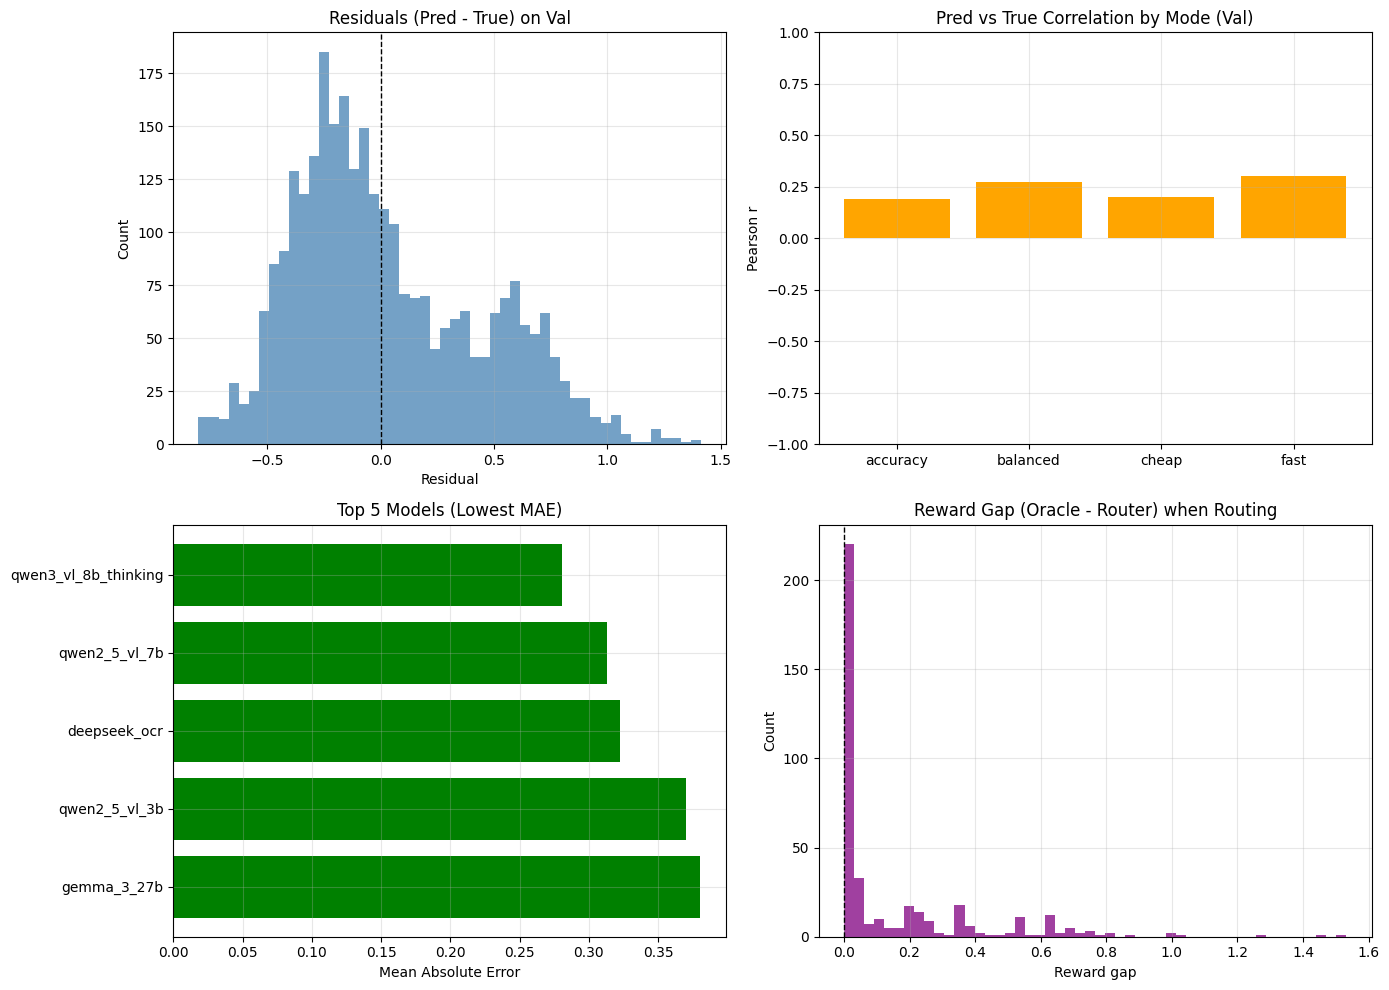


[SUMMARY METRICS]
Mean residual: 0.0309 | Std: 0.4152
  accuracy     r = 0.189
  balanced     r = 0.275
  cheap        r = 0.200
  fast         r = 0.303
Best 5 models by MAE: ['qwen3_vl_8b_thinking', 'qwen2_5_vl_7b', 'deepseek_ocr', 'qwen2_5_vl_3b', 'gemma_3_27b']
Reward gap (oracle - router) mean: 0.1522
Reward gap <= 0 (router >= oracle): 34.0%


In [34]:
# Extra diagnostics: errors and mode-level performance
print("[PERFORMANCE DIAGNOSTICS]")

# Residuals
residuals = val_df_with_preds['pred_reward'] - val_df_with_preds['reward']

# Per-mode correlation
mode_corr = val_df_with_preds.groupby('mode_name')[['pred_reward', 'reward']].corr().unstack().loc[:, ('pred_reward', 'reward')]

# Per-model MAE (top 10 smallest)
per_model_mae = (
    val_df_with_preds
    .assign(abs_err=lambda df: (df['pred_reward'] - df['reward']).abs())
    .groupby('model_name')['abs_err']
    .mean()
    .sort_values()
)

# Reward gap when router disagrees with oracle
reward_gap = results_df['oracle_reward'] - results_df['router_true_reward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residual histogram
axes[0, 0].hist(residuals, bins=50, color='steelblue', alpha=0.75)
axes[0, 0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residuals (Pred - True) on Val')
axes[0, 0].set_xlabel('Residual')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# Correlation per mode
axes[0, 1].bar(mode_corr.index, mode_corr.values, color='orange')
axes[0, 1].set_ylim(-1, 1)
axes[0, 1].set_title('Pred vs True Correlation by Mode (Val)')
axes[0, 1].set_ylabel('Pearson r')
axes[0, 1].grid(alpha=0.3)

# Top models by MAE
top_n = min(10, len(per_model_mae))
axes[1, 0].barh(per_model_mae.head(top_n).index[::-1], per_model_mae.head(top_n).values[::-1], color='green')
axes[1, 0].set_title(f'Top {top_n} Models (Lowest MAE)')
axes[1, 0].set_xlabel('Mean Absolute Error')
axes[1, 0].grid(alpha=0.3)

# Reward gap distribution
axes[1, 1].hist(reward_gap, bins=50, color='purple', alpha=0.75)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('Reward Gap (Oracle - Router) when Routing')
axes[1, 1].set_xlabel('Reward gap')
axes[1, 1].set_ylabel('Count')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\n[SUMMARY METRICS]')
print(f"Mean residual: {residuals.mean():.4f} | Std: {residuals.std():.4f}")
for mode, r in mode_corr.items():
    print(f"  {mode:12s} r = {r:.3f}")
print(f"Best {top_n} models by MAE: {list(per_model_mae.head(top_n).index)}")
print(f"Reward gap (oracle - router) mean: {reward_gap.mean():.4f}")
print(f"Reward gap <= 0 (router >= oracle): {(reward_gap <= 0).mean():.1%}")


## Summary

This notebook demonstrated the **reward-prediction approach** for VLM routing:

1. ✅ Connected to PostgreSQL and loaded real profiling data
2. ✅ Computed multi-objective rewards (accuracy, cheap, fast, balanced)
3. ✅ Built dataset with (sample, model, mode) → reward mapping
4. ✅ Trained transformer router to predict rewards
5. ✅ Evaluated router vs oracle

**Key Results**:
- Router learns to predict rewards with **Pearson correlation ≈ 0.XX** (check val_pearson above)
- Router matches oracle's model choice **XX%** of the time on average
- Router recovers **XX%** of oracle's reward on average

**Next Steps**:
- Tune reward weights in `RewardWeights` config
- Train for more epochs
- Try different text encoders (BERT, RoBERTa)
- Add image features to the router input
- Evaluate on full test set
- Compare against baselines (always biggest, always cheapest, random)